# 03 — `src/data/synth_data.py`: Generating the Synthetic Dataset

This is the module that currently produces our **primary** training data (not just a Harespod gap-filler — see `CLAUDE.md`'s "synthetic-first, adapter ready" decision). It generates fake but physiologically-plausible "expedition" recordings: a simulated subject ascends to altitude, and over 90 minutes either stays fine or develops one of four illness tiers, with realistic sensor noise and individual variation.

**Why synthetic data at all, and why now?** The real dataset (Harespod) has four gaps CLAUDE.md documents: no body temperature, no continuous altitude, no HAPE/HACE cases (you can't ethically induce those in human subjects in a lab), and no severity labels. Rather than block the whole project on a manual Figshare download, this generator lets Days 2-7 proceed immediately, with `harespod_loader.py` ready to blend in real recordings the moment they're downloaded (see the `04_harespod_loader.ipynb` notebook).

We'll import the real functions from `src/data/synth_data.py` and run them here so you see exactly what's happening at each step, with plots.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # prepend project root to sys.path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import synth_data
from src.config import SEVERITY_TIERS

## Step 1: The reference curve — `expected_spo2()`

```python
def expected_spo2(altitude_m: float) -> float:
    drop = (altitude_m / 1000.0) * SPO2_DROP_PER_1000M
    return SPO2_SEA_LEVEL_BASELINE - drop
```

This is deliberately the simplest possible model: SpO2 drops linearly with altitude, starting from 98% at sea level and losing about 3% per 1000m (both numbers live in `config.py`, not hardcoded here). Every trajectory's "how sick is this person" signal is measured as a *deviation from this curve*, not as a raw SpO2 number — because 85% SpO2 is alarming at sea level but might be completely normal at 5000m.

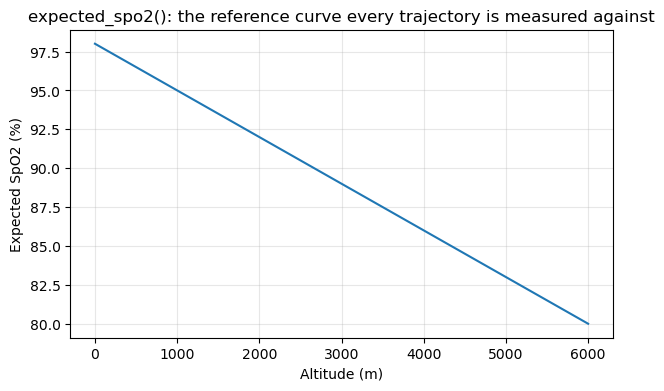

In [2]:
altitudes = np.linspace(0, 6000, 50)  # 50 evenly spaced altitude samples from sea level to 6000m
expected = [synth_data.expected_spo2(a) for a in altitudes]  # reference SpO2 curve: 98% baseline minus 3%/1000m (config.SPO2_DROP_PER_1000M)

plt.figure(figsize=(7, 4))
plt.plot(altitudes, expected)
plt.xlabel("Altitude (m)")
plt.ylabel("Expected SpO2 (%)")
plt.title("expected_spo2(): the reference curve every trajectory is measured against")
plt.grid(alpha=0.3)
plt.show()

## Step 2: Tier profiles — what each severity level "aims for"

```python
@dataclass(frozen=True)
class TierProfile:
    spo2_delta_range: tuple[float, float]     # how far BELOW expected SpO2, in %
    hr_elevation_range: tuple[float, float]   # bpm ABOVE resting HR
    temp_delta_range: tuple[float, float]     # degrees C shift
    progressive: bool                          # keeps worsening, or plateaus?
```

Each of the 5 tiers has a `TierProfile` with **ranges**, not single fixed numbers. Sampling uniformly *within* a range for every simulated subject is what gives the dataset natural within-class variation — every "Mild AMS" case isn't identical, the same way real patients aren't identical.

The `progressive` flag is the key clinical modeling decision from `docs/lls_mapping.md`: Mild AMS and Severe AMS are modeled as **plateauing** (symptoms rise then hold steady — the person is sick but stable), while HAPE risk and HACE risk are modeled as **progressive** (symptoms keep worsening through the whole window, no plateau — matching the clinical idea that these are decompensating, dangerous trajectories that don't self-stabilize).

In [3]:
for tier, profile in synth_data.TIER_PROFILES.items():  # walk all 5 tiers' target ranges (spo2_delta, hr_elevation, temp_delta, progressive flag)
    print(f"{tier:12s}  spo2_delta={profile.spo2_delta_range}  hr_elev={profile.hr_elevation_range}  "
          f"temp_delta={profile.temp_delta_range}  progressive={profile.progressive}")

Normal        spo2_delta=(-1.5, 1.5)  hr_elev=(-5, 8)  temp_delta=(-0.2, 0.2)  progressive=False
Mild AMS      spo2_delta=(4, 8)  hr_elev=(10, 20)  temp_delta=(-0.1, 0.4)  progressive=False
Severe AMS    spo2_delta=(8, 14)  hr_elev=(20, 35)  temp_delta=(0.0, 0.6)  progressive=False
HAPE risk     spo2_delta=(14, 22)  hr_elev=(28, 45)  temp_delta=(-0.1, 0.5)  progressive=True
HACE risk     spo2_delta=(16, 26)  hr_elev=(32, 50)  temp_delta=(-0.1, 0.7)  progressive=True


## Step 3: Class imbalance is intentional

```python
TIER_PREVALENCE = {
    "Normal": 0.55, "Mild AMS": 0.22, "Severe AMS": 0.13,
    "HAPE risk": 0.06, "HACE risk": 0.04,
}
```

Real populations at altitude are mostly fine — severe illness is genuinely rare. `CLAUDE.md` is explicit that this imbalance must be *real and handled* (via class weighting in the models — see the XGBoost/LSTM notebooks), not artificially balanced away by generating equal numbers of each tier. An artificially-balanced synthetic dataset would teach the model a false prior about how common HACE risk actually is, and defeat the purpose of testing whether the models handle imbalance correctly.

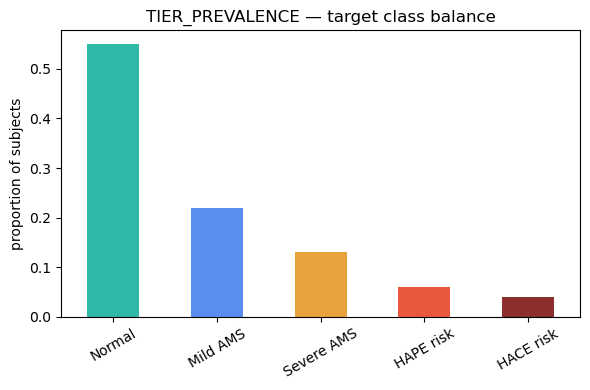

In [4]:
prevalence = pd.Series(synth_data.TIER_PREVALENCE)  # {tier: proportion} -> a Series so it can be bar-plotted directly
prevalence.plot(kind="bar", figsize=(6, 4), color=["#2FB8A6", "#5B8DEF", "#E8A23D", "#E8583D", "#8B2E2E"])  # color list mirrors severity order: teal(Normal) -> blue -> orange -> red -> dark red(HACE risk)
plt.title("TIER_PREVALENCE — target class balance")
plt.ylabel("proportion of subjects")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Step 4: The smooth onset ramp — `_smooth_ramp()`

This is the single most important design choice in the generator, called out in the module docstring: **gradual onset, not step functions**.

```python
def _smooth_ramp(n_samples, onset_fraction, rng):
    onset_start = int(n_samples * onset_fraction)
    ...
    ramp = 1.0 / (1.0 + np.exp(-(t - center) / width))   # sigmoid
    ramp[t < onset_start] = 0.0
    return ramp
```

**Why not just jump straight from "healthy" to "sick" at some fixed minute?** A real physiological deterioration ramps over minutes to hours — a model trained on instant step-function jumps would learn to detect *abrupt discontinuities*, which is not what AMS/HAPE/HACE onset actually looks like, and it would generalize poorly to a real, gradually-worsening patient. So `_smooth_ramp` produces a curve that: stays flat at 0 for a random "lead-in" period (`onset_fraction`, different per subject), then rises smoothly along a sigmoid (slow start, faster middle, plateau at the end) rather than a straight line — because real symptom onset accelerates once it starts, it doesn't ramp at a constant rate.

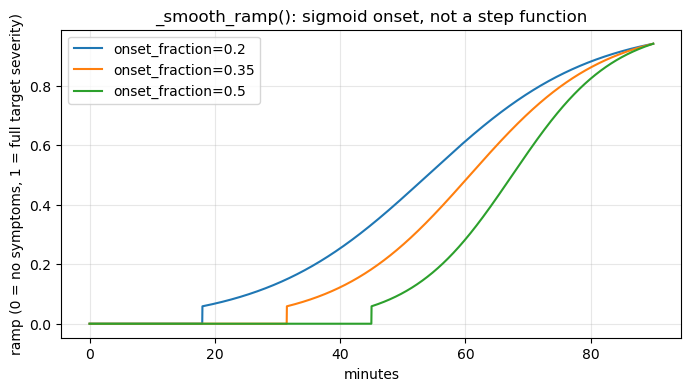

In [5]:
rng = np.random.default_rng(7)  # seeded RNG so the ramp shapes are reproducible across runs
n = 90 * 60  # 90 minutes at 1Hz

fig, ax = plt.subplots(figsize=(8, 4))
for onset_fraction in [0.2, 0.35, 0.5]:  # compare ramps that start symptom onset at 20%/35%/50% of the way through the window
    ramp = synth_data._smooth_ramp(n, onset_fraction, rng)  # sigmoid curve: flat at 0 until onset_fraction, then rises smoothly to 1
    ax.plot(np.arange(n) / 60, ramp, label=f"onset_fraction={onset_fraction}")
ax.set_xlabel("minutes")
ax.set_ylabel("ramp (0 = no symptoms, 1 = full target severity)")
ax.set_title("_smooth_ramp(): sigmoid onset, not a step function")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## Step 5: Simulating one full trajectory — `simulate_trajectory()`

This function pulls everything together for a single subject. Reading the real source top to bottom:

1. **Altitude profile** — ascends smoothly to a randomized cruising altitude in the first ~30% of the window, then holds (nobody teleports to altitude, and the ascent needs to look continuous because `ascent_rate` is later computed *from* this curve).
2. **Per-subject individual variation** — each simulated subject gets its own resting HR, own normal temperature, and an `altitude_sensitivity` multiplier (some people desaturate faster than others at the same altitude). This is what stops the dataset from being a trivial lookup table — two "Mild AMS" subjects produce different numbers.
3. **Symptom onset ramp** — starts only *after* the ascent is mostly done (symptoms follow altitude exposure, they don't precede it), using `_smooth_ramp` from above. If the tier isn't `progressive`, the ramp is clamped to plateau at 0.85 instead of climbing all the way to 1.0's asymptote.
4. **Compose final signals** — `expected_spo2(altitude) - spo2_delta` (the reference curve minus however much this subject's severity ramp has pulled them down), plus Gaussian sensor noise, clipped to physiologically possible bounds.

Let's run it directly and plot one example per tier.

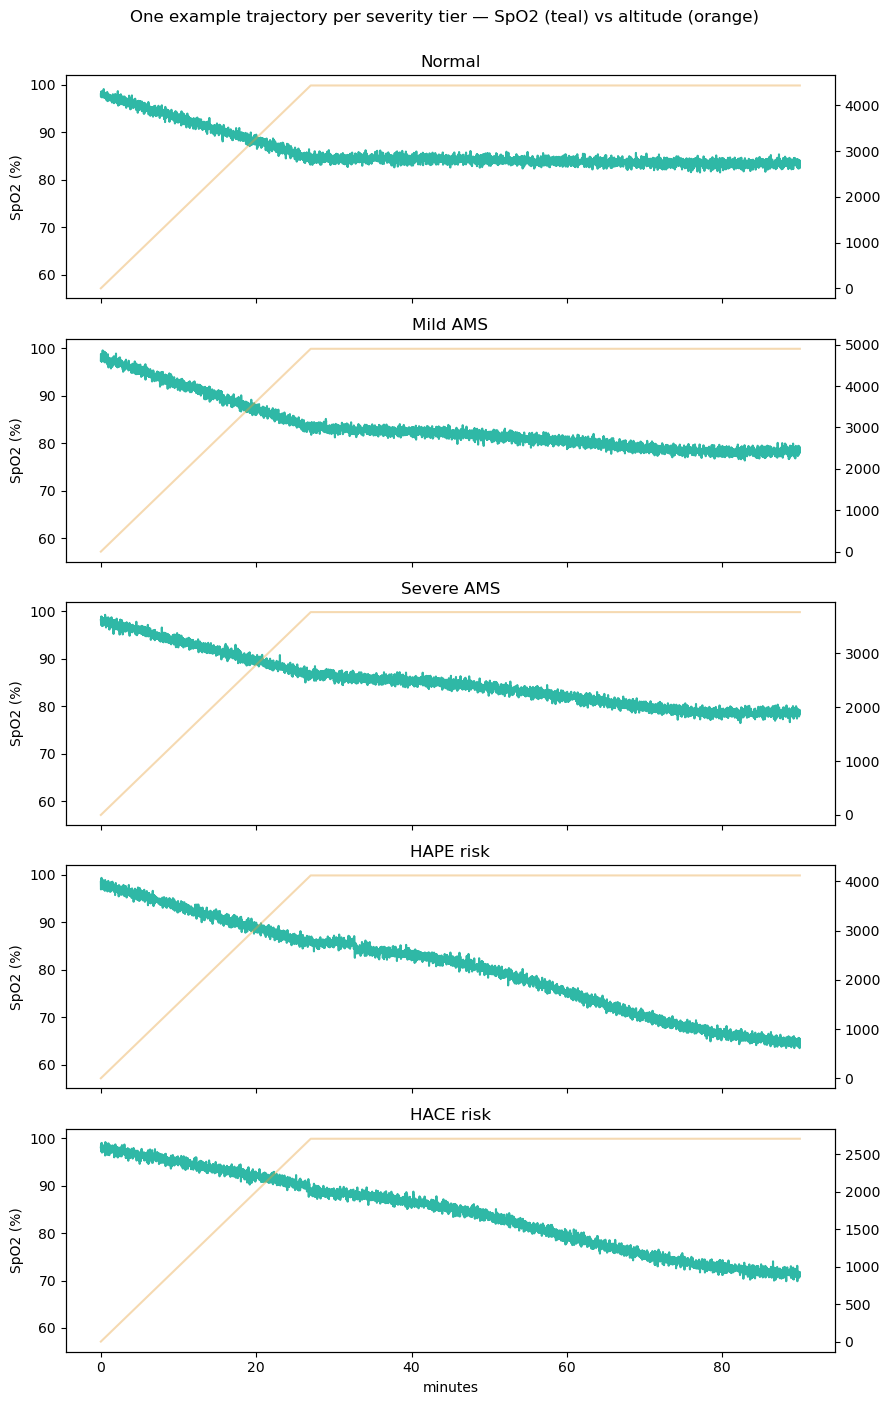

In [6]:
fig, axes = plt.subplots(len(SEVERITY_TIERS), 1, figsize=(9, 14), sharex=True)  # one stacked subplot per tier, sharing the x-axis
rng = np.random.default_rng(42)  # fixed seed (matches config.RANDOM_SEED) for reproducible example trajectories

for ax, tier in zip(axes, SEVERITY_TIERS):  # generate and plot one demo subject per severity tier
    traj = synth_data.simulate_trajectory(f"demo_{tier}", tier, duration_minutes=90, rng=rng)  # full 90-minute simulated trajectory for this tier
    ax.plot(traj["timestamp"] / 60, traj["spo2"], label="SpO2", color="#2FB8A6")  # convert seconds to minutes for the x-axis
    ax2 = ax.twinx()  # second y-axis so altitude (meters) and SpO2 (%) each get their own natural scale
    ax2.plot(traj["timestamp"] / 60, traj["altitude"], color="#E8A23D", alpha=0.4, label="altitude")
    ax.set_title(f"{tier}")
    ax.set_ylabel("SpO2 (%)")
    ax.set_ylim(55, 102)  # fixed y-range across all tiers so severity differences are visually comparable

axes[-1].set_xlabel("minutes")
fig.suptitle("One example trajectory per severity tier — SpO2 (teal) vs altitude (orange)", y=1.0)
fig.tight_layout()
plt.show()

**What to look for in the plot above:** every tier ascends the same way (that's altitude, not illness). The difference is what SpO2 does *after* the ascent — Normal barely deviates from the reference curve, Mild/Severe AMS dip and then hold steady (plateau), and HAPE/HACE risk keep sinking through the whole window (progressive, no recovery) — exactly the distinction `docs/lls_mapping.md` describes.

## Step 6: Building the full population — `generate_dataset()`

```python
def generate_dataset(n_subjects=400, duration_minutes=90, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    tiers = list(TIER_PREVALENCE.keys())
    probs = list(TIER_PREVALENCE.values())
    for i in range(n_subjects):
        tier = rng.choice(tiers, p=probs)
        ...
```

This just repeats `simulate_trajectory()` 400 times, drawing each subject's tier from `TIER_PREVALENCE` so the overall population has realistic class imbalance. `subject_id` (`synth_0000`, `synth_0001`, ...) exists so later stages (`feature_engineering.py`) can split the dataset by whole subjects rather than individual rows — critical for preventing data leakage, covered in the next notebook.

Running this for real (400 subjects × 90 minutes × 1Hz = 2.16 million rows) takes a little while, so here we run a smaller version just to show the mechanism.

In [7]:
small_dataset = synth_data.generate_dataset(n_subjects=60, duration_minutes=20, seed=1)  # smaller/faster demo run (vs. the real 400 subjects x 90 min) just to show the mechanism
print(f"{len(small_dataset):,} rows, {small_dataset['subject_id'].nunique()} subjects")
print()
print(small_dataset["severity_label"].value_counts(normalize=True).round(3))  # actual tier proportions in this small sample, to compare against the TIER_PREVALENCE targets above

72,000 rows, 60 subjects

severity_label
Normal        0.450
Mild AMS      0.267
Severe AMS    0.167
HAPE risk     0.117
Name: proportion, dtype: float64


Compare that to the target `TIER_PREVALENCE` above — close, though with only 60 subjects there's natural sampling noise (the real run uses 400 subjects, which tracks the target proportions more tightly, as you saw in `01_data_exploration.ipynb`).

## Summary

`synth_data.py` turns a handful of clinically-motivated ranges (`TIER_PROFILES`, from `docs/lls_mapping.md`) into thousands of individually-varied, gradually-onsetting, noisy sensor trajectories — the raw material every model in this project trains on. The two ideas worth remembering: **(1)** everything is measured as a deviation from an altitude-adjusted reference curve, not a raw number, and **(2)** onset is always smooth (sigmoid), never a step function, because that's what makes the synthetic data resemble what a real deteriorating patient's sensor stream would actually look like.

**Next notebook:** `04_harespod_loader.ipynb` — the adapter waiting for the real dataset.